# Latent Walk on the Autoencoder

Same interpolation experiment but using the plain AE from `fc_autoencoder_2d.pth`.

with no KL regularizer, the AE's latent space has irregular cluster shapes. A straight line between two encoded digits often crosses those gaps. And the decoder has never been trained to make sense of points there.

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(f"Device: {device}")

Device: cuda


In [14]:
class FCAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 28 * 28), nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z).view(-1, 1, 28, 28), z

ae = FCAutoencoder(latent_dim=2).to(device)
ae.load_state_dict(torch.load("fc_autoencoder_2d.pth", map_location=device))
ae.eval()
print("Loaded fc_autoencoder_2d.pth")

Loaded fc_autoencoder_2d.pth


In [15]:
test_ds = datasets.MNIST(root="./data/", train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
print(f"Test set: {len(test_ds)} images")

Test set: 10000 images


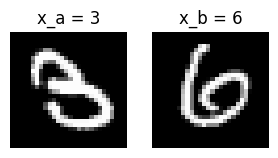

In [16]:
def first_of_class(ds, cls, skip=0):
    seen = 0
    for img, lbl in ds:
        if lbl == cls:
            if seen == skip:
                return img
            seen += 1

CLASS_A, CLASS_B = 3, 6     # try (4, 9), (1, 7), (0, 6) ...
img_a = first_of_class(test_ds, CLASS_A).to(device)
img_b = first_of_class(test_ds, CLASS_B).to(device)

fig, ax = plt.subplots(1, 2, figsize=(3, 1.6))
ax[0].imshow(img_a.cpu().squeeze(), cmap="gray"); ax[0].set_title(f"x_a = {CLASS_A}"); ax[0].axis("off")
ax[1].imshow(img_b.cpu().squeeze(), cmap="gray"); ax[1].set_title(f"x_b = {CLASS_B}"); ax[1].axis("off")
plt.tight_layout(); plt.show()

  z_a = (-0.152, -0.854)  (digit 3)
  z_b = (+7.486, -4.666)  (digit 6)

  step      t        z1        z2
  ----  -----  --------  --------
     0   0.00    -0.152    -0.854
     1   0.05    +0.250    -1.055
     2   0.11    +0.652    -1.255
     3   0.16    +1.054    -1.456
     4   0.21    +1.456    -1.656
     5   0.26    +1.858    -1.857
     6   0.32    +2.260    -2.058
     7   0.37    +2.662    -2.258
     8   0.42    +3.064    -2.459
     9   0.47    +3.466    -2.659
    10   0.53    +3.868    -2.860
    11   0.58    +4.270    -3.061
    12   0.63    +4.672    -3.261
    13   0.68    +5.074    -3.462
    14   0.74    +5.476    -3.663
    15   0.79    +5.878    -3.863
    16   0.84    +6.280    -4.064
    17   0.89    +6.682    -4.264
    18   0.95    +7.084    -4.465
    19   1.00    +7.486    -4.666


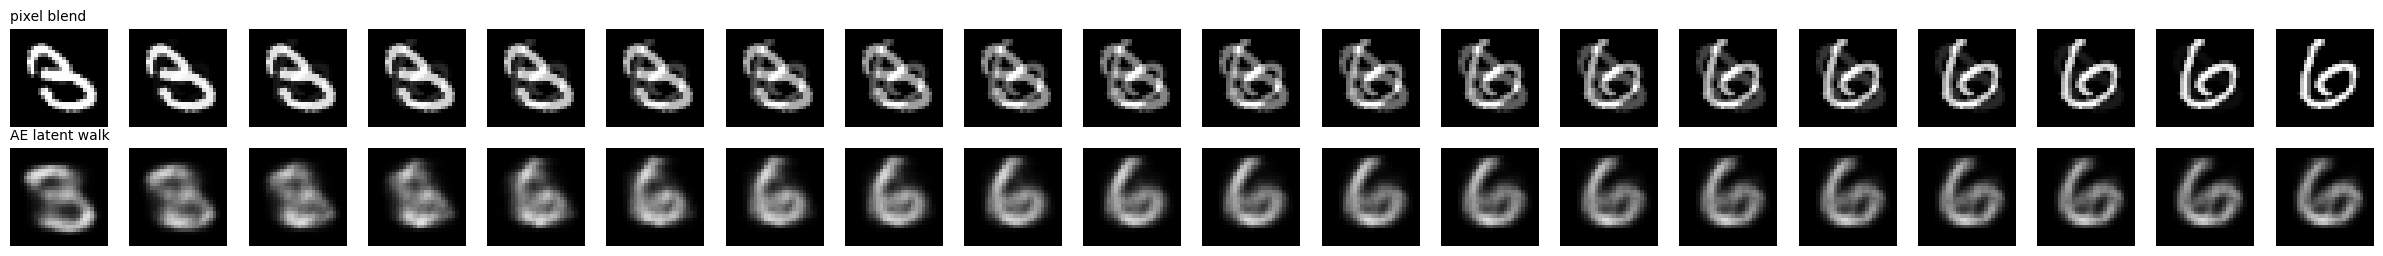

In [17]:
N_STEPS = 20

with torch.no_grad():
    z_a = ae.encoder(img_a.unsqueeze(0))
    z_b = ae.encoder(img_b.unsqueeze(0))

ts = torch.linspace(0, 1, N_STEPS, device=device).unsqueeze(1)
z_path = (1 - ts) * z_a + ts * z_b                # latent-space line
with torch.no_grad():
    decoded = ae.decoder(z_path).view(-1, 28, 28).cpu()

pixel_blend = ((1 - ts.view(-1, 1, 1)).cpu() * img_a.view(1, 28, 28).cpu()
               +  ts.view(-1, 1, 1).cpu()      * img_b.view(1, 28, 28).cpu())

# Print the 2-D latent coordinates at each step
print(f"  z_a = ({z_a[0,0].item():+.3f}, {z_a[0,1].item():+.3f})  (digit {CLASS_A})")
print(f"  z_b = ({z_b[0,0].item():+.3f}, {z_b[0,1].item():+.3f})  (digit {CLASS_B})")
print()
print(f"  {'step':>4s}  {'t':>5s}  {'z1':>8s}  {'z2':>8s}")
print(f"  {'-'*4}  {'-'*5}  {'-'*8}  {'-'*8}")
zp = z_path.cpu()
for j in range(N_STEPS):
    print(f"  {j:>4d}  {ts[j,0].item():>5.2f}  {zp[j,0].item():>+8.3f}  {zp[j,1].item():>+8.3f}")

fig, axes = plt.subplots(2, N_STEPS, figsize=(1.2 * N_STEPS, 2.6))
for j in range(N_STEPS):
    axes[0, j].imshow(pixel_blend[j], cmap="gray", vmin=0, vmax=1); axes[0, j].axis("off")
    axes[1, j].imshow(decoded[j],     cmap="gray", vmin=0, vmax=1); axes[1, j].axis("off")
axes[0, 0].set_title("pixel blend", loc="left", fontsize=10)
axes[1, 0].set_title("AE latent walk", loc="left", fontsize=10)
plt.tight_layout(); plt.show()

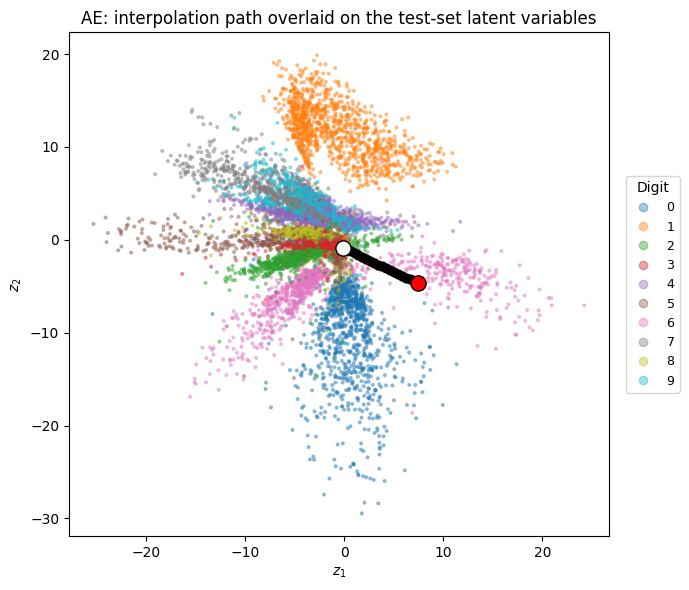

In [20]:
# Encode the whole test set so we can show the path on the AE's latent scatter
all_z, all_lbl = [], []
with torch.no_grad():
    for x, y in test_loader:
        z = ae.encoder(x.to(device))
        all_z.append(z.cpu()); all_lbl.append(y)
all_z = torch.cat(all_z).numpy()
all_lbl = torch.cat(all_lbl).numpy()

z_np = z_path.cpu().numpy()
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(all_z[:, 0], all_z[:, 1], c=all_lbl, cmap="tab10", s=4, alpha=0.4)
ax.plot(z_np[:, 0], z_np[:, 1], "k--", lw=1.5)
ax.scatter(z_np[:, 0], z_np[:, 1], c="black", s=40, zorder=3)
ax.scatter([z_np[0, 0]], [z_np[0, 1]], c="white", edgecolors="black", s=120, zorder=4, label=f"x_a ({CLASS_A})")
ax.scatter([z_np[-1, 0]], [z_np[-1, 1]], c="red", edgecolors="black", s=120, zorder=4, label=f"x_b ({CLASS_B})")
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
ax.set_title("AE: interpolation path overlaid on the test-set latent variables")
ax.legend(*sc.legend_elements(), title="Digit", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout(); plt.show()